# Business Analytics Case Study
## Beyond the Headline Rate: Transparency Scoring for Indian Personal Loans

This notebook performs the complete exploratory analysis and machine-learning comparison for the case study.

**Important dataset note:** the 13,024 rows are standardized analytical scenarios generated from 32 source-derived lender term records across loan amounts and tenures. They are **not** 13,024 independent scraped borrower listings.

### ML objective
Predict the study-defined `transparency_tier` from observable loan and fee characteristics using three models:
1. Logistic Regression
2. Random Forest
3. Gradient Boosting

The primary ML evidence is **5-fold Stratified Group Cross-Validation**, where `lender_name` is the group so scenarios from the same lender do not appear in both training and validation folds.

## 1. Business problem and objectives

The analysis examines the difference between a lender's advertised annual interest rate and a standardized effective APR after incorporating processing fees and GST.

### Objectives
- Quantify the advertised-rate vs effective-APR gap.
- Examine how the gap varies by lender type, loan amount and tenure.
- Construct a study-defined lender-level transparency score.
- Compare three ML models for predicting the resulting analytical tier.
- Translate the results into practical consumer/business insights.

> **Methodological caution:** the transparency tier is constructed from the same pricing-gap behavior that the ML features partially describe. Therefore, ML accuracy is a predictive classification result for this study-defined label; it is not independent validation of an externally observed ground-truth transparency label.

In [1]:
# 2. Imports and display settings
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import kruskal

from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from IPython.display import display

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# 3. Locate and load the dataset
DATA_FILE = "scenario_dataset_13024_source_derived.csv"

candidates = [
    Path("data") / DATA_FILE,
    Path(".") / DATA_FILE,
    Path("..") / "data" / DATA_FILE,
]

data_path = next((p for p in candidates if p.exists()), None)

if data_path is None:
    matches = list(Path.cwd().rglob(DATA_FILE))
    data_path = matches[0] if matches else None

if data_path is None:
    print("Dataset not found. Put the notebook in the project folder containing data/scenario_dataset_13024_source_derived.csv")
else:
    df = pd.read_csv(data_path)
    print(f"Loaded: {data_path}")
    print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
    display(df.head())

Loaded: data/scenario_dataset_13024_source_derived.csv
Shape: 13,024 rows x 20 columns


,lender_name,lender_type,loan_amount_inr,tenure_months,advertised_rate_pct,processing_fee_rule,processing_fee_inr,gst_on_processing_fee_inr,net_disbursed_inr,emi_inr,total_interest_inr,total_repayment_inr,effective_apr_pct,transparency_gap_pp,fee_induced_gap_pp,rate_basis,fee_basis,scenario_type,source_url,collection_date
0,Aditya Birla Finance,NBFC,100000,12,10.99,up_to_pct,4000.0,720.0,95280.0,8837.699408,6052.392895,106052.392895,22.241391,11.251391,11.251391,published starting/lower-bound rate,published fee rule; maximum/fixed rule used,standardized analytical scenario; not an indiv...,https://www.paisabazaar.com/personal-loan/,2026-09-25
1,Aditya Birla Finance,NBFC,100000,18,10.99,up_to_pct,4000.0,720.0,95280.0,6051.391764,8925.051744,108925.051744,18.836117,7.846117,7.846117,published starting/lower-bound rate,published fee rule; maximum/fixed rule used,standardized analytical scenario; not an indiv...,https://www.paisabazaar.com/personal-loan/,2026-09-25
2,Aditya Birla Finance,NBFC,100000,24,10.99,up_to_pct,4000.0,720.0,95280.0,4660.319559,11847.669425,111847.669425,17.102955,6.112955,6.112955,published starting/lower-bound rate,published fee rule; maximum/fixed rule used,standardized analytical scenario; not an indiv...,https://www.paisabazaar.com/personal-loan/,2026-09-25
3,Aditya Birla Finance,NBFC,100000,30,10.99,up_to_pct,4000.0,720.0,95280.0,3827.338050,14820.141499,114820.141499,16.053639,5.063639,5.063639,published starting/lower-bound rate,published fee rule; maximum/fixed rule used,standardized analytical scenario; not an indiv...,https://www.paisabazaar.com/personal-loan/,2026-09-25
4,Aditya Birla Finance,NBFC,100000,36,10.99,up_to_pct,4000.0,720.0,95280.0,3273.398169,17842.334068,117842.334068,15.350473,4.360473,4.360473,published starting/lower-bound rate,published fee rule; maximum/fixed rule used,standardized analytical scenario; not an indiv...,https://www.paisabazaar.com/personal-loan/,2026-09-25


In [3]:
# 4. Dataset structure and quality check
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isna().sum().to_frame("Missing values"))

print("\nDuplicate rows:", df.duplicated().sum())
print("Unique lenders:", df["lender_name"].nunique())
print("Lender types:", df["lender_type"].nunique())

Columns:
['lender_name', 'lender_type', 'loan_amount_inr', 'tenure_months', 'advertised_rate_pct', 'processing_fee_rule', 'processing_fee_inr', 'gst_on_processing_fee_inr', 'net_disbursed_inr', 'emi_inr', 'total_interest_inr', 'total_repayment_inr', 'effective_apr_pct', 'transparency_gap_pp', 'fee_induced_gap_pp', 'rate_basis', 'fee_basis', 'scenario_type', 'source_url', 'collection_date']

Missing values:


,Missing values
lender_name,0
lender_type,0
loan_amount_inr,0
tenure_months,0
advertised_rate_pct,0
processing_fee_rule,0
processing_fee_inr,0
gst_on_processing_fee_inr,0
net_disbursed_inr,0
emi_inr,0



Duplicate rows: 0
Unique lenders: 32
Lender types: 3


## 2. Data preparation

The source-derived lender terms are expanded into standardized scenarios across loan amount and tenure combinations. The effective APR uses the net amount received after processing fee + GST and the EMI stream implied by the advertised annual rate. Conditional foreclosure charges are excluded from the base APR because they are not incurred in every scenario and are not consistently comparable.

In [4]:
# 5. Feature engineering and validation
# Ensure numeric columns have numeric dtype
numeric_cols = [
    "loan_amount_inr", "tenure_months", "advertised_rate_pct",
    "processing_fee_inr", "gst_on_processing_fee_inr",
    "net_disbursed_inr", "emi_inr", "total_interest_inr",
    "total_repayment_inr", "effective_apr_pct",
    "transparency_gap_pp", "fee_induced_gap_pp"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Derived feature used by ML
df["processing_fee_pct_effective"] = (
    df["processing_fee_inr"] / df["loan_amount_inr"] * 100
)

print("Derived processing_fee_pct_effective.")
display(df[["loan_amount_inr", "processing_fee_inr", "processing_fee_pct_effective"]].head())

Derived processing_fee_pct_effective.


,loan_amount_inr,processing_fee_inr,processing_fee_pct_effective
0,100000,4000.0,4.0
1,100000,4000.0,4.0
2,100000,4000.0,4.0
3,100000,4000.0,4.0
4,100000,4000.0,4.0


## 3. Exploratory Data Analysis

In [5]:
# 6. Core descriptive statistics
summary = df[[
    "advertised_rate_pct", "effective_apr_pct", "transparency_gap_pp",
    "fee_induced_gap_pp", "loan_amount_inr", "tenure_months"
]].describe().T

display(summary.round(3))

,count,mean,std,min,25%,50%,75%,max
advertised_rate_pct,13024.0,10.695,1.815,8.0,9.980,10.000,10.992,18.000
effective_apr_pct,13024.0,14.193,3.896,8.5,11.430,13.243,16.054,39.669
transparency_gap_pp,13024.0,3.497,3.179,0.5,1.459,2.576,4.250,27.669
fee_induced_gap_pp,13024.0,3.497,3.179,0.5,1.459,2.576,4.250,27.669
loan_amount_inr,13024.0,550000.000,266937.204,100000.0,325000.000,550000.000,775000.000,1000000.000
tenure_months,13024.0,43.636,21.572,12.0,24.000,42.000,60.000,84.000


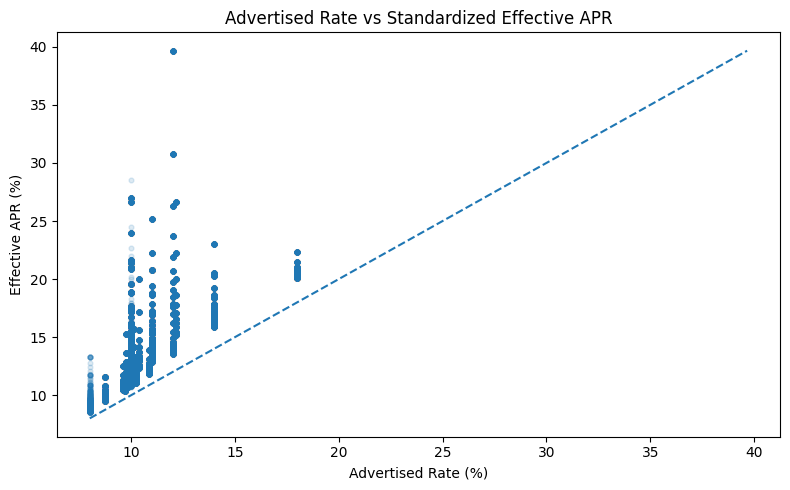

In [6]:
# 7. Advertised rate vs effective APR
plt.figure(figsize=(8, 5))
plt.scatter(
    df["advertised_rate_pct"],
    df["effective_apr_pct"],
    alpha=0.15,
    s=12
)
lims = [
    min(df["advertised_rate_pct"].min(), df["effective_apr_pct"].min()),
    max(df["advertised_rate_pct"].max(), df["effective_apr_pct"].max())
]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Advertised Rate (%)")
plt.ylabel("Effective APR (%)")
plt.title("Advertised Rate vs Standardized Effective APR")
plt.tight_layout()
plt.show()

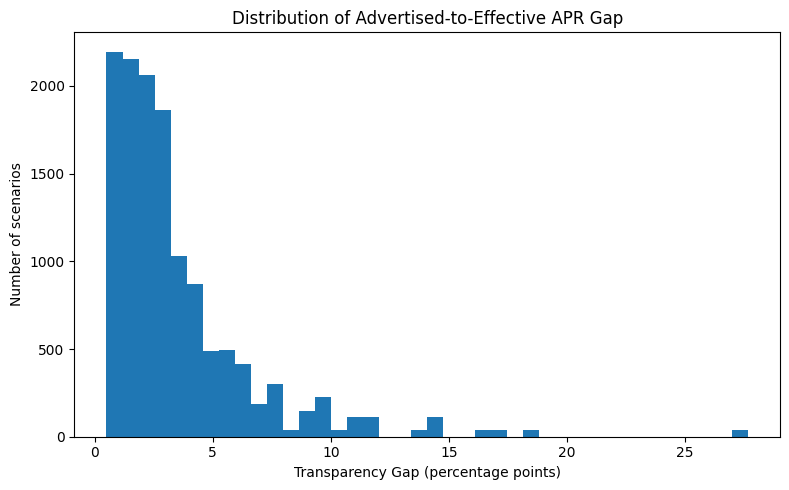

In [7]:
# 8. Distribution of transparency gap
plt.figure(figsize=(8, 5))
plt.hist(df["transparency_gap_pp"], bins=40)
plt.xlabel("Transparency Gap (percentage points)")
plt.ylabel("Number of scenarios")
plt.title("Distribution of Advertised-to-Effective APR Gap")
plt.tight_layout()
plt.show()

,mean,median,count
lender_type,,,
NBFC,5.037,3.866,5698
Private Bank,3.320,2.627,3256
Public Bank,1.483,1.242,4070


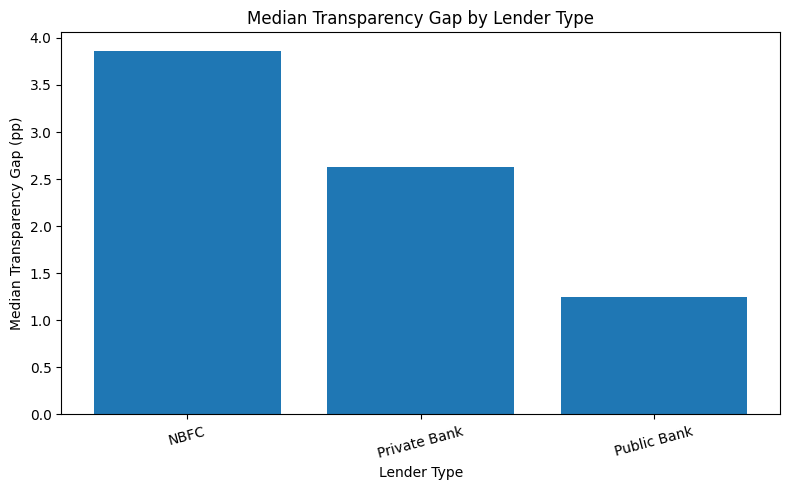

In [8]:
# 9. Gap by lender type
group_gap = (
    df.groupby("lender_type")["transparency_gap_pp"]
      .agg(["mean", "median", "count"])
      .sort_values("median", ascending=False)
)
display(group_gap.round(3))

plt.figure(figsize=(8, 5))
plt.bar(group_gap.index, group_gap["median"])
plt.ylabel("Median Transparency Gap (pp)")
plt.xlabel("Lender Type")
plt.title("Median Transparency Gap by Lender Type")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

,Median gap (pp)
loan_amount_inr,
100000,2.740
125000,2.739
150000,2.681
175000,2.653
200000,2.643
225000,2.633
250000,2.627
275000,2.627
300000,2.607


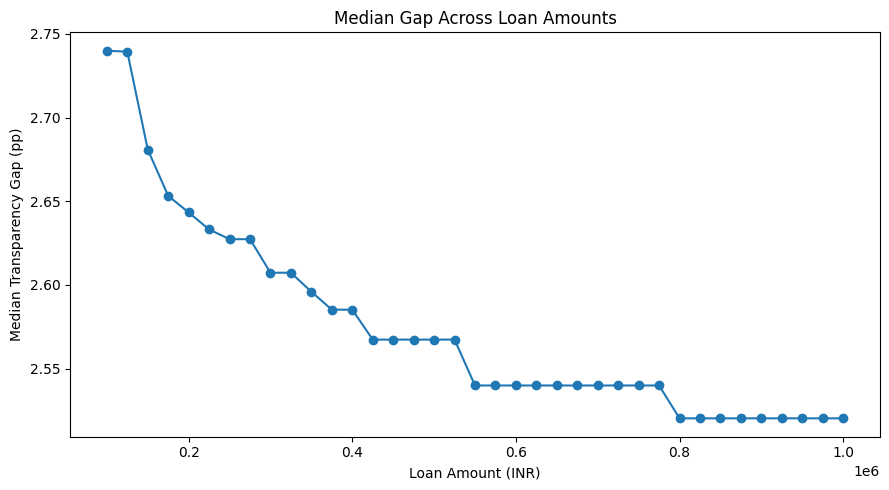

In [9]:
# 10. Gap by loan amount
amount_gap = df.groupby("loan_amount_inr")["transparency_gap_pp"].median()
display(amount_gap.round(3).to_frame("Median gap (pp)"))

plt.figure(figsize=(9, 5))
plt.plot(amount_gap.index, amount_gap.values, marker="o")
plt.xlabel("Loan Amount (INR)")
plt.ylabel("Median Transparency Gap (pp)")
plt.title("Median Gap Across Loan Amounts")
plt.tight_layout()
plt.show()

,Median gap (pp)
tenure_months,
12,5.877
18,4.249
24,3.412
30,2.902
36,2.576
42,2.448
48,2.352
54,2.278
60,2.164


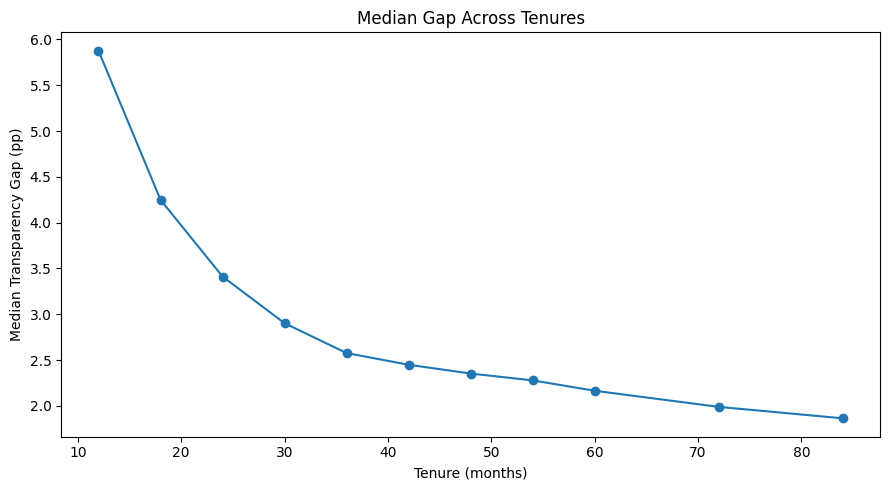

In [10]:
# 11. Gap by tenure
tenure_gap = df.groupby("tenure_months")["transparency_gap_pp"].median()
display(tenure_gap.round(3).to_frame("Median gap (pp)"))

plt.figure(figsize=(9, 5))
plt.plot(tenure_gap.index, tenure_gap.values, marker="o")
plt.xlabel("Tenure (months)")
plt.ylabel("Median Transparency Gap (pp)")
plt.title("Median Gap Across Tenures")
plt.tight_layout()
plt.show()

## 4. Effective APR and transparency gap

For each scenario, `transparency_gap_pp = effective_apr_pct - advertised_rate_pct`. A positive gap means the standardized cost implied by the modeled fees and EMI is above the advertised nominal rate. This is a **study-defined analytical measure**, not a legal finding of misleading advertising.

In [11]:
# 12. Overall key metrics
key_metrics = pd.Series({
    "Scenarios": len(df),
    "Lenders": df["lender_name"].nunique(),
    "Mean advertised rate (%)": df["advertised_rate_pct"].mean(),
    "Mean effective APR (%)": df["effective_apr_pct"].mean(),
    "Median effective APR (%)": df["effective_apr_pct"].median(),
    "Mean transparency gap (pp)": df["transparency_gap_pp"].mean(),
    "Median transparency gap (pp)": df["transparency_gap_pp"].median(),
})
display(key_metrics.to_frame("Value").round(3))

,Value
Scenarios,13024.000
Lenders,32.000
Mean advertised rate (%),10.695
Mean effective APR (%),14.193
Median effective APR (%),13.243
Mean transparency gap (pp),3.497
Median transparency gap (pp),2.576


## 5. Lender-level transparency score

The score is constructed from lender-level median gap and gap variability:

`score = 100 × [1 − (0.8 × gap percentile + 0.2 × variability percentile)]`

The score is then divided into three equal-sized lender groups. The labels are analytical labels defined by this study.

In [12]:
# 13. Construct lender-level score and analytical tier
lender_summary = (
    df.groupby("lender_name")
      .agg(
          lender_type=("lender_type", "first"),
          median_gap_pp=("transparency_gap_pp", "median"),
          sd_gap_pp=("transparency_gap_pp", "std"),
          mean_advertised_rate_pct=("advertised_rate_pct", "mean"),
          mean_effective_apr_pct=("effective_apr_pct", "mean"),
          mean_fee_inr=("processing_fee_inr", "mean")
      )
      .reset_index()
)

lender_summary["gap_percentile"] = lender_summary["median_gap_pp"].rank(pct=True)
lender_summary["variability_percentile"] = lender_summary["sd_gap_pp"].rank(pct=True)
lender_summary["transparency_score"] = 100 * (
    1 - (0.8 * lender_summary["gap_percentile"] +
         0.2 * lender_summary["variability_percentile"])
)

q1, q2 = lender_summary["transparency_score"].quantile([1/3, 2/3])

lender_summary["transparency_tier"] = pd.cut(
    lender_summary["transparency_score"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=["Highly Misleading", "Moderately Misleading", "Transparent"],
    include_lowest=True
)

# Merge lender-level label back to scenario data
df = df.drop(columns=["transparency_tier"], errors="ignore").merge(
    lender_summary[["lender_name", "transparency_score", "transparency_tier"]],
    on="lender_name",
    how="left"
)

print("Lender-level tiers:")
display(
    lender_summary[
        ["lender_name", "lender_type", "median_gap_pp", "sd_gap_pp", "transparency_score", "transparency_tier"]
    ].sort_values("transparency_score", ascending=False).round(3)
)

Lender-level tiers:


,lender_name,lender_type,median_gap_pp,sd_gap_pp,transparency_score,transparency_tier
6,Canara Bank,Public Bank,0.829,0.295,96.875,Transparent
17,Indian Overseas Bank,Public Bank,1.081,0.447,93.750,Transparent
31,Union Bank of India,Public Bank,1.124,0.591,86.562,Transparent
5,Bank of Maharashtra,Public Bank,1.124,0.591,86.562,Transparent
21,Mahindra Finance,NBFC,1.111,0.909,85.625,Transparent
26,Punjab & Sind Bank,Public Bank,1.209,0.596,81.875,Transparent
7,Central Bank of India,Public Bank,1.235,0.597,78.750,Transparent
30,UCO Bank,Public Bank,1.246,0.598,75.625,Transparent
27,Punjab National Bank,Public Bank,1.279,0.599,72.500,Transparent
4,Bank of India,Public Bank,1.347,0.603,69.375,Transparent


,Number of lenders
transparency_tier,
Transparent,11
Moderately Misleading,10
Highly Misleading,11


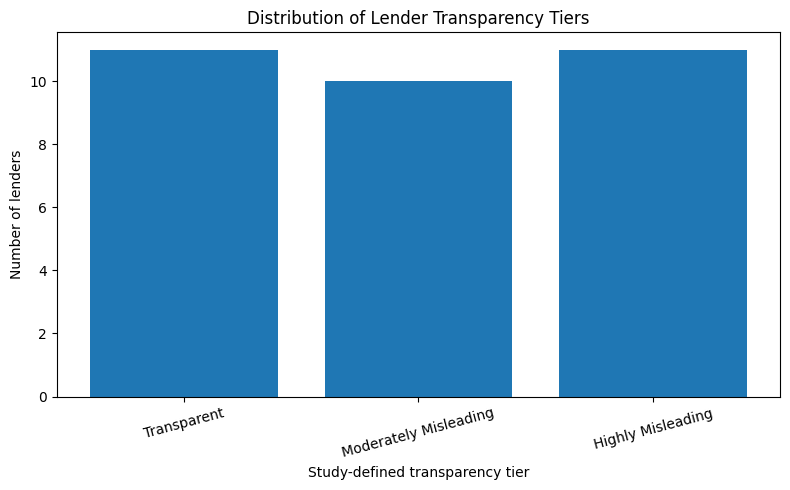

In [13]:
# 14. Tier distribution
tier_counts = lender_summary["transparency_tier"].value_counts().reindex(
    ["Transparent", "Moderately Misleading", "Highly Misleading"]
)
display(tier_counts.to_frame("Number of lenders"))

plt.figure(figsize=(8, 5))
plt.bar(tier_counts.index, tier_counts.values)
plt.ylabel("Number of lenders")
plt.xlabel("Study-defined transparency tier")
plt.title("Distribution of Lender Transparency Tiers")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [14]:
# 15. Kruskal-Wallis test across lender groups
gap_groups = [g["transparency_gap_pp"].values for _, g in df.groupby("lender_name")]
kw_stat, kw_p = kruskal(*gap_groups)
print(f"Kruskal-Wallis H statistic: {kw_stat:.4f}")
print(f"p-value: {kw_p:.6f}")
print("Interpretation: this tests whether the gap distributions differ across lenders; it does not identify causality.")

Kruskal-Wallis H statistic: 8959.3907
p-value: 0.000000
Interpretation: this tests whether the gap distributions differ across lenders; it does not identify causality.


# 6. Machine Learning comparison

### Target
`transparency_tier` is the study-defined lender-level analytical class.

### Predictors
- loan amount
- tenure
- advertised rate
- processing fee
- processing fee as % of loan amount
- lender type

Direct target-derived columns such as `effective_apr_pct`, `transparency_gap_pp`, and `transparency_score` are deliberately excluded to reduce direct target leakage.

### Validation design
A `StratifiedGroupKFold` with 5 folds is used. The group is `lender_name`, preventing the standardized scenarios of the same lender from being split between training and validation data.

In [15]:
# 16. Prepare ML dataset
ml_df = df.copy()

features = [
    "loan_amount_inr",
    "tenure_months",
    "advertised_rate_pct",
    "processing_fee_inr",
    "processing_fee_pct_effective",
    "lender_type"
]

target = "transparency_tier"
group_column = "lender_name"

required = features + [target, group_column]
missing = [c for c in required if c not in ml_df.columns]

if missing:
    print("Missing columns:", missing)
else:
    X = ml_df[features].copy()
    y = ml_df[target].copy()
    groups = ml_df[group_column].copy()
    print("ML dataset ready.")
    print(f"Rows: {len(X):,}")
    print(f"Features: {len(features)}")
    print("Target classes:", list(y.cat.categories) if hasattr(y, "cat") else sorted(y.unique()))
    display(y.value_counts().rename_axis("Tier").to_frame("Scenario count"))

ML dataset ready.
Rows: 13,024
Features: 6
Target classes: ['Highly Misleading', 'Moderately Misleading', 'Transparent']


,Scenario count
Tier,
Highly Misleading,4477
Transparent,4477
Moderately Misleading,4070


In [16]:
# 17. Preprocessing
numeric_features = [
    "loan_amount_inr",
    "tenure_months",
    "advertised_rate_pct",
    "processing_fee_inr",
    "processing_fee_pct_effective"
]
categorical_features = ["lender_type"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
            ]),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline ready.")

Preprocessing pipeline ready.


In [17]:
# 18. Define three ML models
pipelines = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=50, random_state=42, n_jobs=-1
        ))
    ]),
    "Gradient Boosting": Pipeline([
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(
            n_estimators=50, learning_rate=0.05, max_depth=3, random_state=42
        ))
    ])
}

print("Models:")
for name in pipelines:
    print(" -", name)

Models:
 - Logistic Regression
 - Random Forest
 - Gradient Boosting


In [18]:
# 19. 5-fold Stratified Group Cross-Validation
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision_weighted": "precision_weighted",
    "recall_weighted": "recall_weighted",
    "f1_weighted": "f1_weighted"
}

results = []

for name, pipe in pipelines.items():
    print(f"Evaluating {name}...")
    scores = cross_validate(
        pipe, X, y, groups=groups, cv=cv, scoring=scoring,
        n_jobs=1, return_train_score=False
    )
    results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),
        "Precision": scores["test_precision_weighted"].mean(),
        "Recall": scores["test_recall_weighted"].mean(),
        "F1 Score": scores["test_f1_weighted"].mean()
    })

results_df = pd.DataFrame(results)
results_display = results_df.copy()
for col in ["Accuracy", "Accuracy Std", "Precision", "Recall", "F1 Score"]:
    results_display[col] = results_display[col] * 100

results_display = results_display.round(2).sort_values("Accuracy", ascending=False).reset_index(drop=True)
print("\nCross-validation completed successfully.")
display(results_display)

Evaluating Logistic Regression...


Evaluating Random Forest...


Evaluating Gradient Boosting...



Cross-validation completed successfully.


,Model,Accuracy,Accuracy Std,Precision,Recall,F1 Score
0,Logistic Regression,79.70,5.93,85.72,79.70,77.93
1,Random Forest,77.35,14.13,86.48,77.35,75.96
2,Gradient Boosting,76.09,6.57,76.38,76.09,73.16


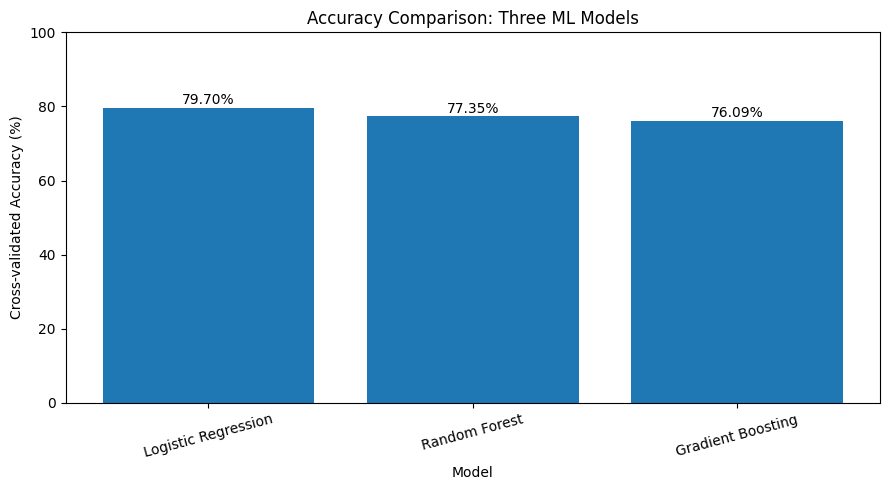

In [19]:
# 20. Accuracy comparison chart
plt.figure(figsize=(9, 5))
chart = results_display.sort_values("Accuracy", ascending=False)
bars = plt.bar(chart["Model"], chart["Accuracy"])
plt.ylabel("Cross-validated Accuracy (%)")
plt.xlabel("Model")
plt.title("Accuracy Comparison: Three ML Models")
plt.ylim(0, 100)

for bar, value in zip(bars, chart["Accuracy"]):
    plt.text(bar.get_x() + bar.get_width()/2, value + 1, f"{value:.2f}%", ha="center")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [20]:
# 21. Full performance comparison
display(results_display)

,Model,Accuracy,Accuracy Std,Precision,Recall,F1 Score
0,Logistic Regression,79.70,5.93,85.72,79.70,77.93
1,Random Forest,77.35,14.13,86.48,77.35,75.96
2,Gradient Boosting,76.09,6.57,76.38,76.09,73.16


In [21]:
# 22. Fit each model on the complete dataset for diagnostic confusion matrices
fitted_models = {}
for name, pipe in pipelines.items():
    pipe.fit(X, y)
    fitted_models[name] = pipe
print("All three models fitted successfully for diagnostics.")

All three models fitted successfully for diagnostics.


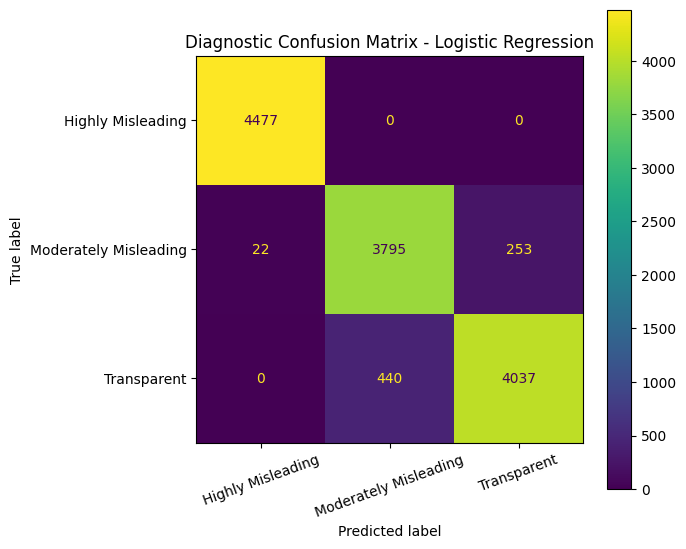

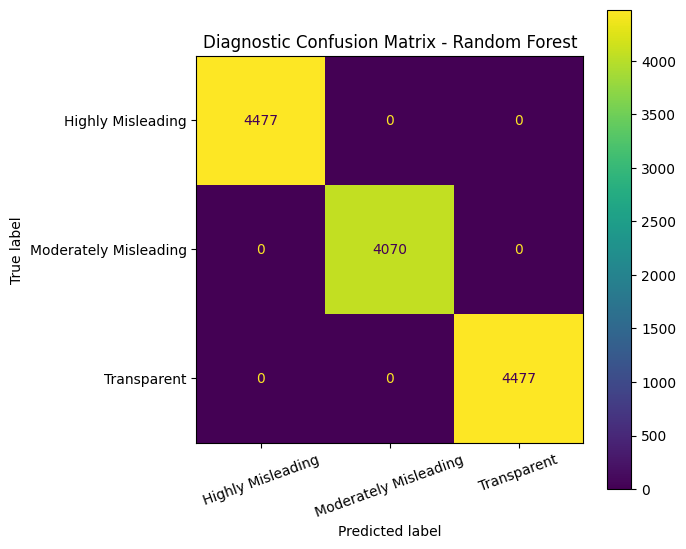

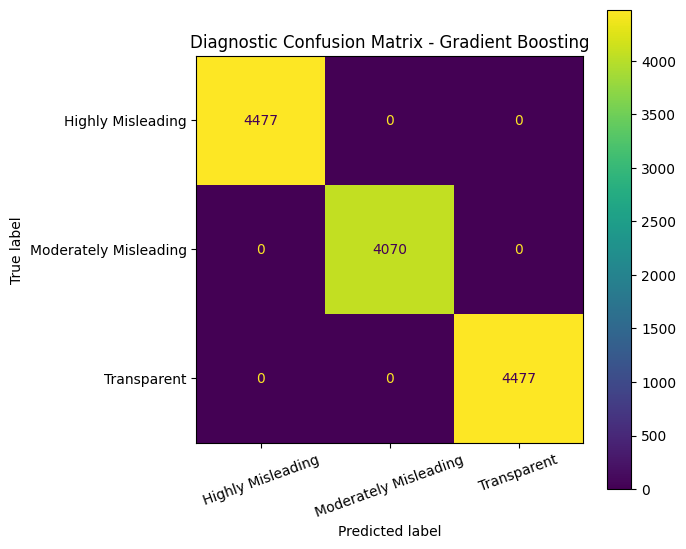

In [22]:
# 23. Confusion matrices (diagnostic, not the primary validation evidence)
for name, model in fitted_models.items():
    pred = model.predict(X)
    cm = confusion_matrix(y, pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(ax=ax, values_format="d")
    ax.set_title(f"Diagnostic Confusion Matrix - {name}")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

In [23]:
# 24. Classification reports (full-data diagnostic)
for name, model in fitted_models.items():
    pred = model.predict(X)
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(classification_report(y, pred, zero_division=0))

Logistic Regression
                       precision    recall  f1-score   support

    Highly Misleading       1.00      1.00      1.00      4477
Moderately Misleading       0.90      0.93      0.91      4070
          Transparent       0.94      0.90      0.92      4477

             accuracy                           0.95     13024
            macro avg       0.94      0.94      0.94     13024
         weighted avg       0.95      0.95      0.95     13024

Random Forest


                       precision    recall  f1-score   support

    Highly Misleading       1.00      1.00      1.00      4477
Moderately Misleading       1.00      1.00      1.00      4070
          Transparent       1.00      1.00      1.00      4477

             accuracy                           1.00     13024
            macro avg       1.00      1.00      1.00     13024
         weighted avg       1.00      1.00      1.00     13024

Gradient Boosting
                       precision    recall  f1-score   support

    Highly Misleading       1.00      1.00      1.00      4477
Moderately Misleading       1.00      1.00      1.00      4070
          Transparent       1.00      1.00      1.00      4477

             accuracy                           1.00     13024
            macro avg       1.00      1.00      1.00     13024
         weighted avg       1.00      1.00      1.00     13024



In [24]:
# 25. Random Forest feature importance
rf_pipe = fitted_models["Random Forest"]
rf_model = rf_pipe.named_steps["model"]
rf_preprocessor = rf_pipe.named_steps["preprocessor"]
feature_names = rf_preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

display(importance_df.head(15).round(4))

,Feature,Importance
0,numeric__processing_fee_pct_effective,0.3099
1,numeric__advertised_rate_pct,0.3026
2,categorical__lender_type_Public Bank,0.1323
3,categorical__lender_type_NBFC,0.0935
4,numeric__processing_fee_inr,0.0878
5,categorical__lender_type_Private Bank,0.0620
6,numeric__loan_amount_inr,0.0104
7,numeric__tenure_months,0.0016


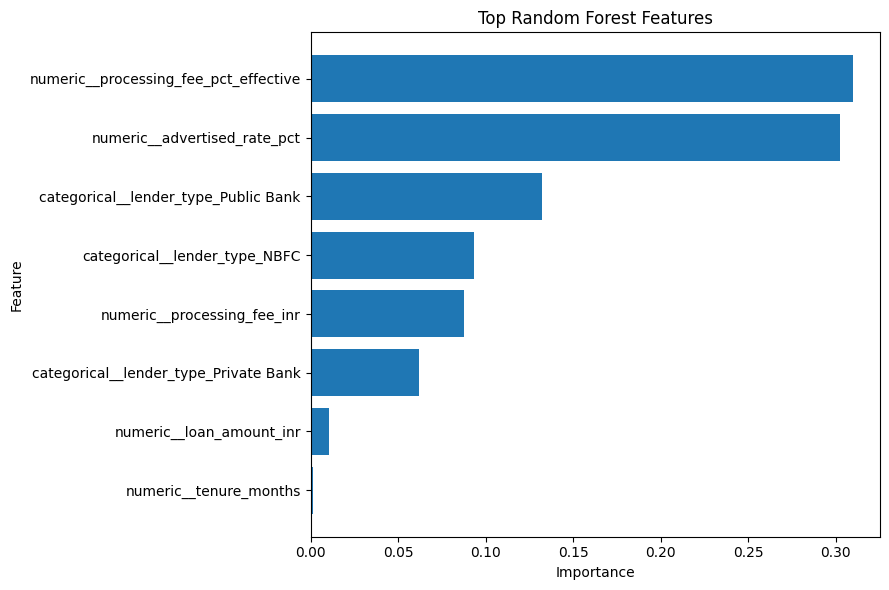

In [25]:
# 26. Feature importance chart
top = importance_df.head(10).sort_values("Importance")
plt.figure(figsize=(9, 6))
plt.barh(top["Feature"], top["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Random Forest Features")
plt.tight_layout()
plt.show()

# 7. Business insights and recommendations

Use the following outputs when writing the final report:

- Compare the **mean and median transparency gap** with the advertised rate.
- Discuss whether lender type, amount and tenure are associated with different gap levels.
- Report the **Kruskal-Wallis p-value** as evidence of differences across lender groups, without claiming causality.
- Report all three ML models using cross-validated accuracy, precision, recall and F1.
- Use the Random Forest importance plot to discuss which observable characteristics contribute most to classification.

### Recommended business actions
1. Compare loans using effective cost rather than the headline rate alone.
2. Display processing fees and GST alongside advertised rates.
3. Use a standardized APR calculation for apples-to-apples comparisons.
4. Treat the transparency score as an analytical screening tool, not a legal or regulatory judgment.
5. For ML, emphasize group-aware cross-validation because many scenarios come from the same lender.

In [26]:
# 27. Automatically generate a concise results summary for the report
best_row = results_display.iloc[0]

print("CASE STUDY RESULTS SUMMARY")
print("-" * 60)
print(f"Scenarios analysed: {len(df):,}")
print(f"Lenders analysed: {df['lender_name'].nunique()}")
print(f"Mean advertised rate: {df['advertised_rate_pct'].mean():.2f}%")
print(f"Mean effective APR: {df['effective_apr_pct'].mean():.2f}%")
print(f"Median effective APR: {df['effective_apr_pct'].median():.2f}%")
print(f"Mean transparency gap: {df['transparency_gap_pp'].mean():.2f} pp")
print(f"Median transparency gap: {df['transparency_gap_pp'].median():.2f} pp")
print(f"Kruskal-Wallis p-value: {kw_p:.6f}")
print(f"Highest cross-validated accuracy: {best_row['Model']} ({best_row['Accuracy']:.2f}%)")
print("\nImportant: ML accuracy predicts a study-defined analytical tier, not an independently observed transparency label.")

CASE STUDY RESULTS SUMMARY
------------------------------------------------------------
Scenarios analysed: 13,024
Lenders analysed: 32
Mean advertised rate: 10.70%
Mean effective APR: 14.19%
Median effective APR: 13.24%
Mean transparency gap: 3.50 pp
Median transparency gap: 2.58 pp
Kruskal-Wallis p-value: 0.000000
Highest cross-validated accuracy: Logistic Regression (79.70%)

Important: ML accuracy predicts a study-defined analytical tier, not an independently observed transparency label.


# 8. Conclusion

This notebook provides the reproducible analysis pipeline for the case study. The central measure is the gap between the advertised nominal rate and a standardized effective APR after modeled processing fees and GST. The ML comparison uses three models and group-aware cross-validation so that lender scenarios are not artificially mixed between training and validation.

### References / source notes
- Paisabazaar public personal-loan comparison material — source used for lender term records; see `SOURCE_NOTES.md` in the project.
- Tantri & Vishen (2025), *Does transparency about banks’ lending costs lower firms’ borrowing costs? Evidence from India*, Journal of Accounting and Economics.
- Ali & Marisetty, *Are FinTech lending apps harmful? Evidence from user experience in the Indian market*, British Accounting Review.
- Sidharta, Nurdina & Putri (2024), *The Effect of Interest Rate, Administrative Fees, and Risk on Online Lending Decisions on Fintech Lending Applications*, IJEBAR.

**Submission reminder:** do not describe the 13,024 scenario rows as 13,024 independently scraped listings. Describe them as standardized scenarios derived from source lender terms.